# TESSCut FITS sanity check notebook

Use this notebook to inspect a downloaded FITS file and determine whether it contains a usable light curve, a very small cutout product, or only metadata.

It is especially useful for cases like:
`VSX_ZTF_J093330.97+500857.6_TIC_841017673_TESSCut.fits`


## What this notebook checks

1. File size and basic existence
2. HDU list summary
3. Primary header keywords
4. Table/image content in each HDU
5. Whether the file looks like a stitched light curve or a TESSCut target-pixel/cutout product
6. If possible, extract and plot time-series columns
7. Give a final sanity verdict


In [1]:
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# === CHANGE THIS TO YOUR LOCAL FILE ===
fits_path = Path('data_pipeline/TESSCache/VSX_ZTF_J093330.97+500857.6_TIC_841017673_TESSCut.fits')

# Optional: if your downloader writes elsewhere, replace the path above with an absolute path.
fits_path


PosixPath('data_pipeline/TESSCache/VSX_ZTF_J093330.97+500857.6_TIC_841017673_TESSCut.fits')

In [2]:
if not fits_path.exists():
    raise FileNotFoundError(f'File not found: {fits_path}')

file_size = fits_path.stat().st_size
print(f'File: {fits_path}')
print(f'Size: {file_size:,} bytes ({file_size/1024:.1f} KB)')

if file_size < 100_000:
    print('WARNING: File is quite small. This does not automatically mean bad, but it deserves inspection.')


File: data_pipeline/TESSCache/VSX_ZTF_J093330.97+500857.6_TIC_841017673_TESSCut.fits
Size: 57,600 bytes (56.2 KB)


In [3]:
with fits.open(fits_path) as hdul:
    print(hdul.info())


Filename: data_pipeline/TESSCache/VSX_ZTF_J093330.97+500857.6_TIC_841017673_TESSCut.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      27   ()      
  1  LIGHTCURVE    1 BinTableHDU     26   1262R x 7C   [D, E, E, J, D, D, J]   
None


In [4]:
def print_primary_header_summary(header):
    keys_of_interest = [
        'SIMPLE', 'BITPIX', 'NAXIS', 'EXTEND',
        'TELESCOP', 'INSTRUME', 'ORIGIN', 'CREATOR',
        'OBJECT', 'TICID', 'MISSION', 'SECTOR', 'CAMERA', 'CCD',
        'DATE', 'DATE-OBS', 'DATE-END', 'TIMESYS'
    ]
    print('Primary header summary:')
    for k in keys_of_interest:
        if k in header:
            print(f'  {k}: {header[k]}')

with fits.open(fits_path) as hdul:
    print_primary_header_summary(hdul[0].header)


Primary header summary:
  SIMPLE: True
  BITPIX: 8
  NAXIS: 0
  EXTEND: True
  TELESCOP: TESS
  INSTRUME: None
  ORIGIN: Unofficial data product
  CREATOR: lightkurve.LightCurve.to_fits()
  OBJECT: 143.379029724236, 50.1493216357517
  MISSION: TESS
  SECTOR: 21
  CAMERA: 2
  CCD: 3
  DATE: 2026-04-19


In [5]:
def summarize_hdu(hdu, idx):
    print('\n' + '='*80)
    print(f'HDU {idx}: name={hdu.name!r}, class={type(hdu).__name__}')
    print(f'  header NAXIS={hdu.header.get("NAXIS")}, XTENSION={hdu.header.get("XTENSION")}')

    data = hdu.data
    if data is None:
        print('  No data payload')
        return

    if hasattr(data, 'shape'):
        print(f'  data shape: {data.shape}')
    if hasattr(data, 'dtype'):
        print(f'  dtype: {data.dtype}')

    # Binary/ascii table case
    names = getattr(data, 'names', None)
    if names is not None:
        print(f'  table columns ({len(names)}): {list(names)}')
        print(f'  row count: {len(data)}')
        for col in list(names)[:12]:
            arr = data[col]
            try:
                finite = np.isfinite(arr).sum() if np.issubdtype(arr.dtype, np.number) else 'n/a'
            except Exception:
                finite = 'n/a'
            print(f'    {col}: dtype={arr.dtype}, sample={arr[:3]!r}, finite={finite}')
        return

    # Image-like case
    if isinstance(data, np.ndarray):
        if data.size > 0 and np.issubdtype(data.dtype, np.number):
            finite = np.isfinite(data).sum()
            print(f'  finite values: {finite}/{data.size}')
            if finite > 0:
                print(f'  min={np.nanmin(data)}, max={np.nanmax(data)}, mean={np.nanmean(data)}')

with fits.open(fits_path) as hdul:
    for i, hdu in enumerate(hdul):
        summarize_hdu(hdu, i)



HDU 0: name='PRIMARY', class=PrimaryHDU
  header NAXIS=0, XTENSION=None
  No data payload

HDU 1: name='LIGHTCURVE', class=BinTableHDU
  header NAXIS=2, XTENSION=BINTABLE
  data shape: (1262,)
  dtype: (numpy.record, [('TIME', '>f8'), ('FLUX', '>f4'), ('FLUX_ERR', '>f4'), ('CADENCENO', '>i4'), ('MOM_CENTR1', '>f8'), ('MOM_CENTR2', '>f8'), ('QUALITY', '>i4')])
  table columns (7): ['TIME', 'FLUX', 'FLUX_ERR', 'CADENCENO', 'MOM_CENTR1', 'MOM_CENTR2', 'QUALITY']
  row count: 1262
    TIME: dtype=>f8, sample=array([1870.45294189, 1870.47375488, 1870.49456787], dtype='>f8'), finite=1262
    FLUX: dtype=>f4, sample=array([3.9766812, 3.7097566, 3.4799526], dtype='>f4'), finite=1262
    FLUX_ERR: dtype=>f4, sample=array([0.00703293, 0.00702676, 0.00700652], dtype='>f4'), finite=1262
    CADENCENO: dtype=>i4, sample=array([0, 1, 2], dtype='>i4'), finite=1262
    MOM_CENTR1: dtype=>f8, sample=array([1166.65956373, 1166.6553222 , 1166.65240681], dtype='>f8'), finite=1262
    MOM_CENTR2: dtype=>f

## Try to identify whether this is a light-curve FITS or a cutout/TPF-like FITS

Heuristics:
- Light-curve FITS often have a binary table with columns like `TIME`, `FLUX`, `PDCSAP_FLUX`, `SAP_FLUX`, etc.
- TESSCut/cutout products often contain image cubes or target-pixel-like arrays rather than a final 1D light curve.


In [6]:
TIME_COL_CANDIDATES = ['TIME', 'BJD', 'TIMECORR']
FLUX_COL_CANDIDATES = ['FLUX', 'SAP_FLUX', 'PDCSAP_FLUX', 'KSPSAP_FLUX', 'RAW_FLUX']

time_candidates = []
flux_candidates = []

with fits.open(fits_path) as hdul:
    for i, hdu in enumerate(hdul):
        data = hdu.data
        names = getattr(data, 'names', None)
        if names is None:
            continue
        names_upper = {n.upper(): n for n in names}
        for t in TIME_COL_CANDIDATES:
            if t in names_upper:
                time_candidates.append((i, names_upper[t]))
        for f in FLUX_COL_CANDIDATES:
            if f in names_upper:
                flux_candidates.append((i, names_upper[f]))

print('Time column candidates:', time_candidates)
print('Flux column candidates:', flux_candidates)


Time column candidates: [(1, 'TIME')]
Flux column candidates: [(1, 'FLUX')]


In [7]:
def first_matching_pair(hdul):
    for i, hdu in enumerate(hdul):
        data = hdu.data
        names = getattr(data, 'names', None)
        if names is None:
            continue
        names_upper = {n.upper(): n for n in names}
        time_col = None
        flux_col = None
        for t in TIME_COL_CANDIDATES:
            if t in names_upper:
                time_col = names_upper[t]
                break
        for f in FLUX_COL_CANDIDATES:
            if f in names_upper:
                flux_col = names_upper[f]
                break
        if time_col and flux_col:
            return i, time_col, flux_col
    return None, None, None

with fits.open(fits_path) as hdul:
    hdu_idx, time_col, flux_col = first_matching_pair(hdul)

print('Selected pair:', hdu_idx, time_col, flux_col)


Selected pair: 1 TIME FLUX


Finite rows: 1262 / 1262
Time span: 1870.452942 to 1897.765137  (delta=27.312195)
Flux stats: min=-0.0847926, max=7.97458, mean=0.344231, std=1


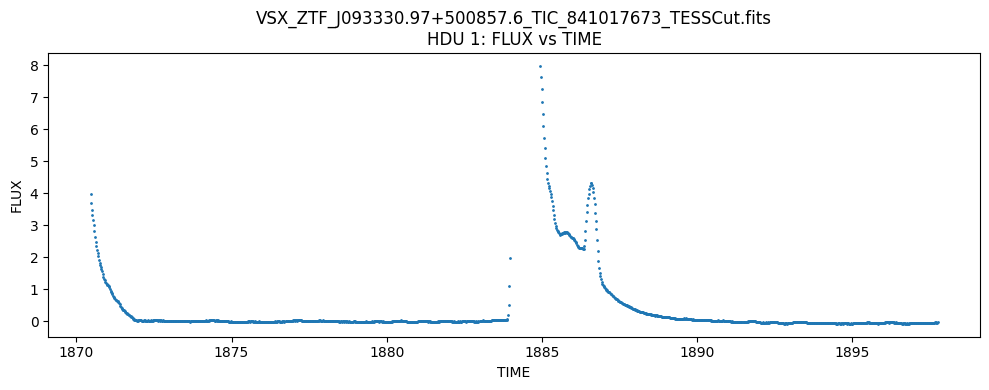

In [8]:
if hdu_idx is not None:
    with fits.open(fits_path) as hdul:
        table = hdul[hdu_idx].data
        time = np.asarray(table[time_col], dtype=float)
        flux = np.asarray(table[flux_col], dtype=float)

    finite = np.isfinite(time) & np.isfinite(flux)
    time_f = time[finite]
    flux_f = flux[finite]

    print(f'Finite rows: {finite.sum()} / {len(time)}')
    if len(time_f) > 0:
        print(f'Time span: {time_f.min():.6f} to {time_f.max():.6f}  (delta={time_f.max()-time_f.min():.6f})')
        print(f'Flux stats: min={flux_f.min():.6g}, max={flux_f.max():.6g}, mean={flux_f.mean():.6g}, std={flux_f.std():.6g}')

        plt.figure(figsize=(10, 4))
        plt.plot(time_f, flux_f, '.', ms=2)
        plt.xlabel(time_col)
        plt.ylabel(flux_col)
        plt.title(f'{fits_path.name}\nHDU {hdu_idx}: {flux_col} vs {time_col}')
        plt.tight_layout()
        plt.show()
    else:
        print('No finite TIME/FLUX rows found.')
else:
    print('Could not find a standard TIME+FLUX table pair. This may be a cutout/TPF-like FITS rather than a final light curve FITS.')


In [9]:
def classify_fits_file(path):
    with fits.open(path) as hdul:
        has_time_flux = False
        has_image_cube = False
        reasons = []

        for i, hdu in enumerate(hdul):
            data = hdu.data
            if data is None:
                continue

            names = getattr(data, 'names', None)
            if names is not None:
                names_upper = {n.upper() for n in names}
                if 'TIME' in names_upper and ('FLUX' in names_upper or 'SAP_FLUX' in names_upper or 'PDCSAP_FLUX' in names_upper):
                    has_time_flux = True
                    reasons.append(f'HDU {i} contains recognizable time/flux columns')

            if isinstance(data, np.ndarray) and data.ndim >= 2:
                has_image_cube = True
                reasons.append(f'HDU {i} contains image-like array with shape {data.shape}')

    if has_time_flux:
        verdict = 'LIKELY_FINAL_LIGHT_CURVE_FITS'
    elif has_image_cube:
        verdict = 'LIKELY_TESSCUT_OR_TARGET_PIXEL_FILE'
    else:
        verdict = 'UNCLEAR_OR_METADATA_ONLY'

    return verdict, reasons

verdict, reasons = classify_fits_file(fits_path)
print('Final verdict:', verdict)
for r in reasons:
    print('-', r)


Final verdict: LIKELY_FINAL_LIGHT_CURVE_FITS
- HDU 1 contains recognizable time/flux columns


## Optional: inspect a suspected image HDU

If the file looks like a TESSCut/TPF-style product, this cell tries to visualize the first image-like HDU.


In [10]:
with fits.open(fits_path) as hdul:
    shown = False
    for i, hdu in enumerate(hdul):
        data = hdu.data
        if isinstance(data, np.ndarray) and data.size > 0 and data.ndim >= 2:
            arr = data
            # If cube-like, show first frame; otherwise show directly
            if arr.ndim == 3:
                img = arr[0]
            elif arr.ndim >= 4:
                img = arr.reshape((-1,) + arr.shape[-2:])[0]
            else:
                img = arr

            plt.figure(figsize=(5, 5))
            plt.imshow(img, origin='lower')
            plt.colorbar(label='Pixel value')
            plt.title(f'{fits_path.name}\nPreview of HDU {i} ({hdu.name})')
            plt.tight_layout()
            plt.show()
            shown = True
            break
    if not shown:
        print('No image-like HDU found to display.')


No image-like HDU found to display.


## Suggested interpretation

- If the file contains a clear TIME/FLUX table with many finite rows, the 57 KB size may still be acceptable for a short or compact light-curve FITS.
- If the file mostly contains image-like arrays or only minimal metadata, then it is probably not yet a final extracted light curve and the downloader may be saving the wrong object for the TESSCut branch.
- If the file contains very few rows, all-NaN data, or no recognizable flux columns, treat it as suspicious and inspect the TESSCut extraction code path.
